# **Subset CONUS and run ParFlow-CLM**

To launch this notebook interactively in a Jupyter notebook-like browser interface, please click the "Launch Binder" button below. Note that Binder may take several minutes to launch.

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/hydroframe/subsettools-binder/HEAD?labpath=subsettools%2Fconus2_subsetting_transient.ipynb)

This notebook walks through an example of subsetting a HUC8 from the CONUS2 domain. This example will subset everything needed to do a transient run with ParFlow-CLM. 
This is includes all hydrogeologic datasets as well as climate forcing data from CW3E. All of the data is written to a folder for the specified days to run. This example uses the template runscript conus2_pfclm_transient_solid.yaml and edits it to correspond with the domain subset. It also sets-up and performs the designed simulation. The result will be model output pressure and saturation pfbs according to the days specified.

### This notebook has two principal sections: 
1. Subset all static inputs and climate forcings from a CONUS run stored in Hydrodata 
2. Load and alter a reference run to set up and perform your ParFlow-CLM subset.

### Import the required libraries

In [1]:
#import matplotlib.pyplot as plt
import numpy as np
import os
from parflow import Run
from parflow.tools.io import read_pfb, read_clm
from parflow.tools.fs import mkdir
from parflow.tools.settings import set_working_directory
import subsettools as st
import hf_hydrodata as hf

In [2]:
# You need to register on https://hydrogen.princeton.edu/pin before you can use the hydrodata utilities
#hf.register_api_pin("your_email", "your_pin")

### 1. Define variables to access datasets in Hydrodata to subset and define write paths

#### We will be testing with the Middle James-Buffalo watershed in Virginia for this example

REMEMBER: CONUS 1 and 2 have different domains, a HUC that will run in CONUS2 may not be in the CONUS1 domain

- HUC ID: 02080203
- Size: 5240 km^2 (ni = 91, nj = 89)   

#### Set your variables to specify which static and climate forcing data you would like to subset in Hydrodata

In [3]:
capillary = True #status of capillary forcing -- true or false
if capillary:
    runname = "MA_via_conus2"
else:
    runname = "no_cap_MA_via_conus2"


#[34.739932; -98.420500]; [35.031552 -97.721777]
# provide a way to create a subset from the conus domain (huc, lat/lon bbox currently supported)
# hucs = ["11130302"]
# provide information about the datasets you want to access for run inputs using the data catalog
# start = "2006-10-01"
# end = "2007-10-01"

#worked for 2620 hours: best case
start = "2019-01-01"
end = "2023-01-01"

grid = "conus2"
var_ds = "conus2_domain"
forcing_ds = "CW3E"
# cluster topology
P = 2
Q = 2

# set the directory paths where you want to write your subset files
home = "/scratch/network/ms6985" #make scratch home again
base_dir = os.path.join(home, "subsettools_tutorial")
input_dir = os.path.join(base_dir, "inputs", f"{runname}_{grid}_{end[:4]}WY")
output_dir = os.path.join(base_dir, "outputs")
static_write_dir = os.path.join(input_dir, "static")
mkdir(static_write_dir)
forcing_dir = os.path.join(input_dir, "forcing")
mkdir(forcing_dir)
pf_out_dir = os.path.join(output_dir, f"{runname}_{grid}_{end[:4]}WY")
mkdir(pf_out_dir)

# Set the PARFLOW_DIR path to your local installation of ParFlow.
# This is only necessary if this environment variable is not already set.
# os.environ["PARFLOW_DIR"] = "/path/to/your/parflow/installation"
os.environ["PARFLOW_DIR"] = "/home/SHARED/software/parflow/75cacb0/"

# load your preferred template runscript
reference_run = st.get_template_runscript(grid, "transient", "solid", pf_out_dir)

### 2. Get the desired ParFlow i/j bbox from user provided geospatial information 

In [4]:
#	I	J
#[42.3433620411624929,-72.2925311203326686]	4,140	2221
#[42.692484048100727,-72.2925311203326686]	4129	2257
# [42.692484048100727,-71.9502074688803788]	4166	2239
# [42.3433620411624929,-71.9502074688803788]	4155	2265
		
#MIN	4,129	2,221
#MAX	4,166	2265	
#Size	37	44


#lat, lon = st.ij_to_latlon(4129, 2221, grid="conus2")
#print(lat, lon)

import hf_hydrodata as hf

(i, j) = hf.to_ij("conus2", 42.3433620411624929,-72.2925311203326686)
#ij_bounds = hf.to_ij("conus2", *[31.651836, -115.982367, 31.759219, -115.902573])
print(i,j)
(lat, lon) = hf.to_latlon("conus2", i, j)
print(lat, lon)

4140 2221
42.33722989330806 -72.30607896307912


In [5]:
#new subsettools function

from subsettools._error_checking import (
    _validate_huc_list,
    _validate_grid,
    _validate_latlon_list,
    _validate_dir,
    _validate_mask,
)
import hf_hydrodata


def define_latlon_tile_domain(latlon_bounds, grid):
    """Define a domain by latitude/longitude bounds.

    The domain is defined by the grid ij bounds of a bounding box formed by the
    latitude/longitude bounds (latlon_bounds) relative to the selected conus grid
    and a mask for that bounding box indicating which cells are active CONUS
    points.

    Args:
        latlon_bounds (List[List[float]]): list of the form [[lat1, lon1],
            [lat2, lon2]]. [lat1, lon1] and [lat2, lon2] define the northwest
            and southeast corners of the desired box respectively.
        grid (str):  The spatial grid that the ij indices are calculated relative
            to and that the subset data will be returned on. Possible values:
            “conus1” or “conus2”.

    Returns:
        A tuple (bounds, mask).

        Bounds is a tuple of the form (imin, jmin, imax, jmax) representing the
        bounds in the conus grid of the area defined by the latlon_bounds. imin,
        jmin, imax, jmax are the west, south, east and north sides of the box
        respectively and all i,j indices are calculated relative to the lower
        southwest corner of the domain.

        Mask is a 2D numpy.ndarray that indicates which cells inside the bounding
        box are active CONUS points (for example, if ocean is part of the bounding
        box the corresponding cells will not be part of the mask).

    Example:

    .. code-block:: python

        grid_bounds, mask = define_latlon_domain(
            latlon_bounds=[[37.91, -91.43], [37.34, -90.63]], grid="conus2"
        )
    """


    _validate_grid(grid)
    _validate_latlon_list(latlon_bounds)
    if len(latlon_bounds) != 2:
        raise ValueError("latlon_bounds must contain exactly two points.")

    #all 4 corner points
    lat1, lon1 = latlon_bounds[0]
    lat2, lon2 = latlon_bounds[1]

    combinations = [
    [lat1, lon1],
    [lat1, lon2],
    [lat2, lon1],
    [lat2, lon2]
    ]

    grid = grid.lower()
    
    points_ij = [
        hf_hydrodata.to_ij(grid, lat, lon)
        for lat, lon in combinations
    ]
    

    i_vals = [pt[0] for pt in points_ij]
    j_vals = [pt[1] for pt in points_ij]
    
    imin, imax = min(i_vals), max(i_vals) + 1
    jmin, jmax = min(j_vals), max(j_vals) + 1
    
    grid_bounds = (imin, jmin, imax, jmax)

    nj = grid_bounds[3] - grid_bounds[1]
    ni = grid_bounds[2] - grid_bounds[0]

    mask = np.ones(((nj,ni)),dtype=int)

    #modify mask
    II = grid_bounds[0]+ np.array([i for i in range(ni)],dtype=int)
    JJ = grid_bounds[1]+ np.array([i for i in range(nj)],dtype=int)
    III,JJJ = np.meshgrid(II,JJ) #creating meshgrid

    LAT = np.ones((nj,ni)); LON = np.ones((nj,ni))
    #calculate lat and long
    for i in range(III.shape[0]):
        for j in range(III.shape[1]):
            LAT[i, j], LON[i, j] = hf.to_latlon(grid, III[i, j], JJJ[i, j])

    print(np.min([lat1,lat2]))
    mask[LAT<np.min([lat1,lat2])] = 0; mask[LAT>np.max([lat1,lat2])] = 0;
    mask[LON<np.min([lon1,lon2])] = 0; mask[LON>np.max([lon1,lon2])] = 0;

    return grid_bounds, mask.astype(int)



ij_bounds, mask  = define_latlon_tile_domain(
    [[42.3433620411624929,-72.2925311203326686], [42.692484048100727,-71.9502074688803788]], grid="conus2"
)

print(ij_bounds)
#print([[42.3433620411624929,-72.2925311203326686], [42.692484048100727,-71.9502074688803788]]))

42.34336204116249
(4129, 2221, 4167, 2266)


In [6]:
'''
#ij_bounds, mask = st.define_huc_domain(hucs=hucs, grid=grid)
#ij_bounds, mask  = st.define_latlon_domain(
#    latlon_bounds=[[42.3433620411624929,-72.2925311203326686], [42.692484048100727,-71.9502074688803788]], grid="conus2"
#)
ij_bounds = (4129, 2221,4166,2265) #This covers all 4 corner points
#34.739932; -98.420500]; [35.031552 -97.721777

print("ij_bound returns [imin, jmin, imax, jmax]")
print(f"bounding box: {ij_bounds}")

nj = ij_bounds[3] - ij_bounds[1]
ni = ij_bounds[2] - ij_bounds[0]
print(f"nj: {nj}")
print(f"ni: {ni}")
mask = np.ones(((nj,ni)),dtype=int)

#modify mask
II = ij_bounds[0]+ np.array([i for i in range(ni)],dtype=int)
JJ = ij_bounds[1]+ np.array([i for i in range(nj)],dtype=int)
print(np.shape(II),II)
print(np.shape(JJ),JJ)
III,JJJ = np.meshgrid(II,JJ) #creating meshgrid
print(np.shape(III))
print(np.shape(mask))

LAT = np.ones((nj,ni)); LON = np.ones((nj,ni))
#calculate lat and long
for i in range(III.shape[0]):
    for j in range(III.shape[1]):
        LAT[i, j], LON[i, j] = hf.to_latlon("conus2", III[i, j], JJJ[i, j])

print(LAT); print(LON)

mask[LAT<42.3433620411624929] = 0; mask[LAT>42.692484048100727] = 0;
mask[LON<-72.2925311203326686] = 0; mask[LON>-71.9502074688803788] = 0;
'''

'\n#ij_bounds, mask = st.define_huc_domain(hucs=hucs, grid=grid)\n#ij_bounds, mask  = st.define_latlon_domain(\n#    latlon_bounds=[[42.3433620411624929,-72.2925311203326686], [42.692484048100727,-71.9502074688803788]], grid="conus2"\n#)\nij_bounds = (4129, 2221,4166,2265) #This covers all 4 corner points\n#34.739932; -98.420500]; [35.031552 -97.721777\n\nprint("ij_bound returns [imin, jmin, imax, jmax]")\nprint(f"bounding box: {ij_bounds}")\n\nnj = ij_bounds[3] - ij_bounds[1]\nni = ij_bounds[2] - ij_bounds[0]\nprint(f"nj: {nj}")\nprint(f"ni: {ni}")\nmask = np.ones(((nj,ni)),dtype=int)\n\n#modify mask\nII = ij_bounds[0]+ np.array([i for i in range(ni)],dtype=int)\nJJ = ij_bounds[1]+ np.array([i for i in range(nj)],dtype=int)\nprint(np.shape(II),II)\nprint(np.shape(JJ),JJ)\nIII,JJJ = np.meshgrid(II,JJ) #creating meshgrid\nprint(np.shape(III))\nprint(np.shape(mask))\n\nLAT = np.ones((nj,ni)); LON = np.ones((nj,ni))\n#calculate lat and long\nfor i in range(III.shape[0]):\n    for j in ran

### 3. Make the mask and solid file
You only do this if you providin a huc or list of hucs. Otherwise, the reference run provided is for a box domain.

In [7]:
!pip show subsettools

Name: subsettools
Version: 2.0.9
Summary: Subsetting tools and utilities for ParFlow
Home-page: 
Author: George Artavanis, Amanda Triplett
Author-email: 
License: MIT
Location: /home/SHARED/virtual-environments/parflow-shared/conda/lib/python3.11/site-packages
Requires: hf-hydrodata, numpy, pandas, pftools, pylint, requests
Required-by: cssi_evaluation


In [8]:
mask_solid_paths = st.write_mask_solid(mask=mask, grid=grid, write_dir=static_write_dir)

Wrote mask.pfb
Wrote solidfile and mask_vtk with total z of 2000.0 meters


### 4. Subset the static ParFlow inputs
Two options to subset static inputs. 
1. subset_static(): This function when provided with a variable dataset hosted on Hydrodata will subset all static inputs required to do a baseline run from the default argument var_list without the user specifying specific files. Pressure is the steady state pressure. If a user would like the override this, they may pass in their own value for var_list and their specifed variables in the target dataset will be subset. 

2. subset_press_init(): This function will write the subset pressure of the last hour in the last day before your start date in the given time zone. If no such pressure file exists in the hydrodata run dataset specifed, no file will be written. The function assumes UTC0 as the default and will return 11PM UTC0. You can override this by providing a timezone. 

**Note: In when working with the CONUS2 domain, there are no currently no available transient runs, so we will start runs from the steady state pressure file returned by subset_static().** 

In [9]:
static_paths = st.subset_static(ij_bounds, dataset=var_ds, write_dir=static_write_dir)

/tmp/ipykernel_1801084/800467743.py:1: DeprecationWarning: Note that for subsettools versions >= 2.0.0, this function will raise a ValueError if a variable in var_list is not supported in the dataset. (In older versions, it just printed an error message and continued executing normally). You can check in the HydroData documentation which variables are contained in each dataset (https://hf-hydrodata.readthedocs.io/en/latest/available_data.html).
  static_paths = st.subset_static(ij_bounds, dataset=var_ds, write_dir=static_write_dir)


Wrote slope_x.pfb in specified directory.
Wrote slope_y.pfb in specified directory.
Wrote pf_indicator.pfb in specified directory.
Wrote mannings.pfb in specified directory.
Wrote pf_flowbarrier.pfb in specified directory.
Wrote pme.pfb in specified directory.
Wrote ss_pressure_head.pfb in specified directory.


# Copying output of the spin up

In [10]:
import shutil
#print(static_write_dir)

print(pf_out_dir)

print(f'Copying is done from {pf_out_dir}/../MA_via_conus2_cycle4_conus2_2019WY/MA_via_conus2_cycle4.out.press.08760.pfb to', f'{static_write_dir}/ss_pressure_head.pfb')
shutil.copy(f'{pf_out_dir}/../MA_via_conus2_cycle4_conus2_2019WY/MA_via_conus2_cycle4.out.press.08760.pfb', f'{static_write_dir}/ss_pressure_head.pfb')


/scratch/network/ms6985/subsettools_tutorial/outputs/MA_via_conus2_conus2_2023WY
Copying is done from /scratch/network/ms6985/subsettools_tutorial/outputs/MA_via_conus2_conus2_2023WY/../MA_via_conus2_cycle4_conus2_2019WY/MA_via_conus2_cycle4.out.press.08760.pfb to /scratch/network/ms6985/subsettools_tutorial/inputs/MA_via_conus2_conus2_2023WY/static/ss_pressure_head.pfb


'/scratch/network/ms6985/subsettools_tutorial/inputs/MA_via_conus2_conus2_2023WY/static/ss_pressure_head.pfb'

### 5. Configure CLM drivers
This function will get the clm drivers that are associated with your run dataset (same dataset as where you got your initial pressure file). Vegm, vegp and drv_clmin will be written into your specified static input directory. 

In [11]:
clm_paths = st.config_clm(ij_bounds, start=start, end=end, dataset=var_ds, write_dir=static_write_dir)

copied vegp
subset vegm
copied drv_clmin
edited drv_clmin


### 6. Subset the climate forcing

This function will write all variables needed to run CLM for your specified forcing dataset, on your specified grid, subset to the i/j boundary that was returned previously within the specified start and end date. This function assumes UTC0 by default, but you can override it by providing a timezone.

In [12]:
forcing_paths = st.subset_forcing(
    ij_bounds,
    grid=grid,
    start=start,
    end=end,
    dataset=forcing_ds,
    write_dir=forcing_dir,
)

Finished writing north_windspeed to folder
Finished writing precipitation to folder
Finished writing specific_humidity to folder
Finished writing downward_shortwave to folder
Finished writing atmospheric_pressure to folder
Finished writing air_temp to folder
Finished writing east_windspeed to folder
Finished writing downward_longwave to folder


### 7. Spot check subset static and climate forcing with plotting

#### Check a static input

(45, 38)


Text(0.5, 1.0, 'pf_indicator.pfb')

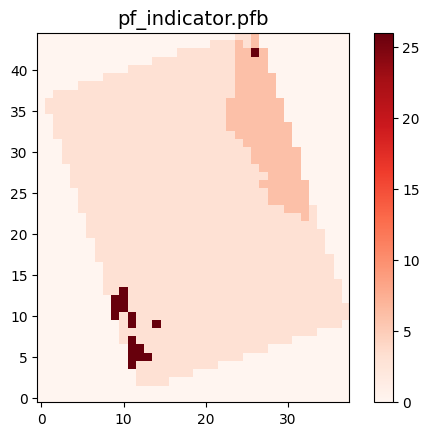

In [13]:
import matplotlib.pyplot as plt
os.chdir(static_write_dir)
file_name = "pf_indicator.pfb"
data = read_pfb(file_name)[7] 
print(data.shape)

plt.imshow(data*mask, cmap="Reds", origin="lower")
#plt.imshow(data, cmap="Reds", origin="lower")
plt.colorbar()
plt.title(file_name, fontsize = 14)

### 8. Set up a baseline run from a reference yaml
This function will return the correct template yaml file to do your run based on the grid, if you're doing spin-up and if you're using a solid file with the necessary keys changed to run your subset with selected climate forcing at baseline for your specified start and end dates.

In [14]:
runscript_path = st.edit_runscript_for_subset(
    ij_bounds,
    runscript_path=reference_run,
    runname=runname,
    forcing_dir=forcing_dir,
)

Solver: Field BinaryOutDir is not part of the expected schema <class 'parflow.tools.database.generated.Solver'>
New runname: MA_via_conus2 provided, a new yaml file will be created
Climate forcing directory has been changed to /scratch/network/ms6985/subsettools_tutorial/inputs/MA_via_conus2_conus2_2023WY/forcing  in runscript.
ComputationalGrid.NY set to 45 and NX to 38
GeomInput.domaininput.InputType detected as SolidFile, no additional keys to change for subset
Updated runscript written to /scratch/network/ms6985/subsettools_tutorial/outputs/MA_via_conus2_conus2_2023WY


### 9. Copy over your static files to your run directory
You may only need to do this once, or you may want to copy subset static files to different run directories for different runs.

In [15]:
st.copy_files(read_dir=static_write_dir, write_dir=pf_out_dir)

### 10. Change the file names in your runscript if desired
If you have changed the name of a static input file either from those used in the reference yamls provided, or have changed the name of an individual file for an ensemble or other experiment, you can change it with this function by providing the target runscript (yaml or pfidb) and the new file name(s) as an arguments. Only those arguments with a specified file name will be updated

In [16]:
init_press_path = os.path.basename(static_paths["ss_pressure_head"])
depth_to_bedrock_path = os.path.basename(static_paths["pf_flowbarrier"])

runscript_path = st.change_filename_values(
    runscript_path=runscript_path,
    init_press=init_press_path,
    depth_to_bedrock = depth_to_bedrock_path
)

Solver: Field BinaryOutDir is not part of the expected schema <class 'parflow.tools.database.generated.Solver'>
Initial pressure filename changed to ss_pressure_head.pfb
Depth to bedrock filename changed to pf_flowbarrier.pfb
Updated runscript written to /scratch/network/ms6985/subsettools_tutorial/outputs/MA_via_conus2_conus2_2023WY


### 11. Change processor topology if desired and then distribute your inputs and forcings to match the new topology

In [17]:
runscript_path = st.dist_run(
    topo_p=P,
    topo_q=Q,
    runscript_path=runscript_path,
    dist_clim_forcing=True,
)

Solver: Field BinaryOutDir is not part of the expected schema <class 'parflow.tools.database.generated.Solver'>
Distributing your climate forcing
Distributed mask.pfb with NZ 1
Distributed slope_x.pfb with NZ 1
Distributed slope_y.pfb with NZ 1
Distributed pf_indicator.pfb with NZ 10
Distributed mannings.pfb with NZ 1
Distributed pf_flowbarrier.pfb with NZ 10
Distributed pme.pfb with NZ 10
Distributed ss_pressure_head.pfb with NZ 10


### 12. Do a baseline run.
Load in the yaml run file you've created which is in the same folder as your static forcings and points to your climate forcing data. This assumes you do not want to make any changes from the parent model you used (Ex. conus1 baseline) and will run your subset at baseline conditions. Outputs should be almost identical to the parent model at your subset location for the same time period if you make no additional changes.

**Notes about run speed**

There are several things that may cause your run to take longer than expect. First, look at the file ending with your_runname.out.kinsol.log. If it is updating, it means your system is trying to solve. 

1. You may be trying to run too large a domain for the number of cores 
2. There is heavy rain on the day or days you selected, making the system harder to solve
3. The initial (time 0) step can often take longer to run
4. You have made a large change to one of your inputs. The change you made may mean the initial pressure file doesn't "match up" with your input. Try to run your subset model in spinup mode first, and then return to transient mode.

In [18]:
set_working_directory(f"{pf_out_dir}")
print(pf_out_dir)

# load the specified run script
run = Run.from_definition(runscript_path)
print(f"Loaded run with runname: {run.get_name()}")

if not capillary:  #only run for no capillary case
    # #new alpha
    run.Geom.domain.RelPerm.Alpha =    100.0
    run.Geom.s1.RelPerm.Alpha =        100.0
    run.Geom.s2.RelPerm.Alpha =        100.0
    run.Geom.s3.RelPerm.Alpha =        100.0
    run.Geom.s4.RelPerm.Alpha =        100.0
    run.Geom.s5.RelPerm.Alpha =        100.0
    run.Geom.s6.RelPerm.Alpha =        100.0
    run.Geom.s7.RelPerm.Alpha =        100.0
    run.Geom.s8.RelPerm.Alpha =        100.0
    run.Geom.s9.RelPerm.Alpha =        100.0
    run.Geom.s10.RelPerm.Alpha =       100.0
    run.Geom.s11.RelPerm.Alpha =       100.0
    run.Geom.s12.RelPerm.Alpha =       100.0
    run.Geom.s13.RelPerm.Alpha =       100.0

    run.Geom.domain.Saturation.Alpha =    100.0
    run.Geom.s1.Saturation.Alpha =        100.0
    run.Geom.s2.Saturation.Alpha =        100.0
    run.Geom.s3.Saturation.Alpha =        100.0
    run.Geom.s4.Saturation.Alpha =        100.0
    run.Geom.s5.Saturation.Alpha =        100.0
    run.Geom.s6.Saturation.Alpha =        100.0
    run.Geom.s7.Saturation.Alpha =        100.0
    run.Geom.s8.Saturation.Alpha =        100.0
    run.Geom.s9.Saturation.Alpha =        100.0
    run.Geom.s10.Saturation.Alpha =       100.0
    run.Geom.s11.Saturation.Alpha =       100.0
    run.Geom.s12.Saturation.Alpha =       100.0
    run.Geom.s13.Saturation.Alpha =       100.0
    
# run.Solver.MaxIter = 25000
# run.Solver.Drop = 1e-20
# run.Solver.AbsTol = 1e-8
# run.Solver.MaxConvergenceFailures = 8#20
# run.Solver.Nonlinear.MaxIter = 2000#1000
# run.Solver.Nonlinear.ResidualTol = 1e-4#1e-6
# run.Solver.Nonlinear.EtaChoice =  "EtaConstant"
# run.Solver.Nonlinear.EtaValue = 0.001
# run.Solver.Nonlinear.UseJacobian = True
# run.Solver.Nonlinear.DerivativeEpsilon = 1e-10#1e-16
# run.Solver.Nonlinear.StepTol = 1e-10#1e-15
# run.Solver.Nonlinear.Globalization = "LineSearch"
# run.Solver.Linear.KrylovDimension = 150#70
# run.Solver.Linear.MaxRestarts = 5#2

# # physical properties
# run.Solver.CLM.EvapBeta = "Linear"
# run.Solver.CLM.VegWaterStress = "Saturation"
# run.Solver.CLM.ResSat = 0.1
# run.Solver.CLM.WiltingPoint = 0.12
# run.Solver.CLM.FieldCapacity = 0.98
# run.Solver.CLM.IrrigationType = "none"
# run.Solver.CLM.RootZoneNZ = 4
# run.Solver.CLM.SoiLayer = 4


run.Solver.PrintSubsurfData = True
run.Solver.PrintPressure = True
run.Solver.PrintSaturation = True
run.Solver.PrintMask = True
run.Solver.PrintVelocities = False
run.Solver.PrintEvapTrans = False
run.Solver.CLM.SingleFile = True
run.Solver.PrintSlopes = True

run.Solver.WriteCLMBinary = False
run.Solver.PrintCLM = True

# The following line is setting the run just for 10 hours for testing purposes
run.TimingInfo.StopTime = 35064#36000#35073#140268 #43800

# The following line updates the root name of your climate forcing. You can comment it out if using NLDAS datasets. 
run.Solver.CLM.MetFileName = 'CW3E'

run.run(working_directory=pf_out_dir)

/scratch/network/ms6985/subsettools_tutorial/outputs/MA_via_conus2_conus2_2023WY
Solver: Field BinaryOutDir is not part of the expected schema <class 'parflow.tools.database.generated.Solver'>
Loaded run with runname: MA_via_conus2
: Field _run_file is not part of the expected schema <class 'parflow.tools.core.Run'>

# ==============================================================================
# ParFlow directory
#  - /home/SHARED/software/parflow/75cacb0/
# ParFlow version
#  - 3.13.0
# Working directory
#  - /scratch/network/ms6985/subsettools_tutorial/outputs/MA_via_conus2_conus2_2023WY
# ParFlow database
#  - MA_via_conus2.pfidb
# ==============================================================================


# ==============================================================================
# ParFlow ran successfully
# ==============================================================================



In [19]:
pf_out_dir

'/scratch/network/ms6985/subsettools_tutorial/outputs/MA_via_conus2_conus2_2023WY'